In [1]:
import pandas as pd 
import numpy as np
df = pd.read_csv("/kaggle/input/datasets/ridwanul02/usa-housing/USA_Housing.csv")
df.shape

(5000, 7)

In [2]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [5]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.dtypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                          object
dtype: object

In [8]:
df['Price'].describe()

count    5.000000e+03
mean     1.232073e+06
std      3.531176e+05
min      1.593866e+04
25%      9.975771e+05
50%      1.232669e+06
75%      1.471210e+06
max      2.469066e+06
Name: Price, dtype: float64

count    5.000000e+03
mean     1.232073e+06
std      3.531176e+05
min      1.593866e+04
25%      9.975771e+05
50%      1.232669e+06
75%      1.471210e+06
max      2.469066e+06
Name: Price, dtype: float64


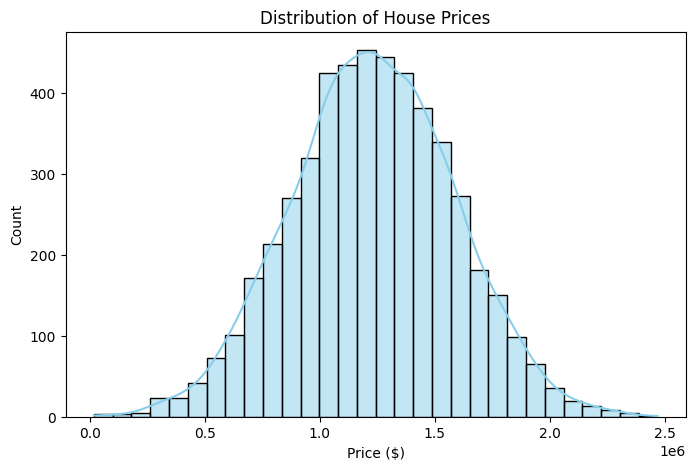

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

price_stats = df["Price"].describe()
print(price_stats)
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True, bins=30, color="skyblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

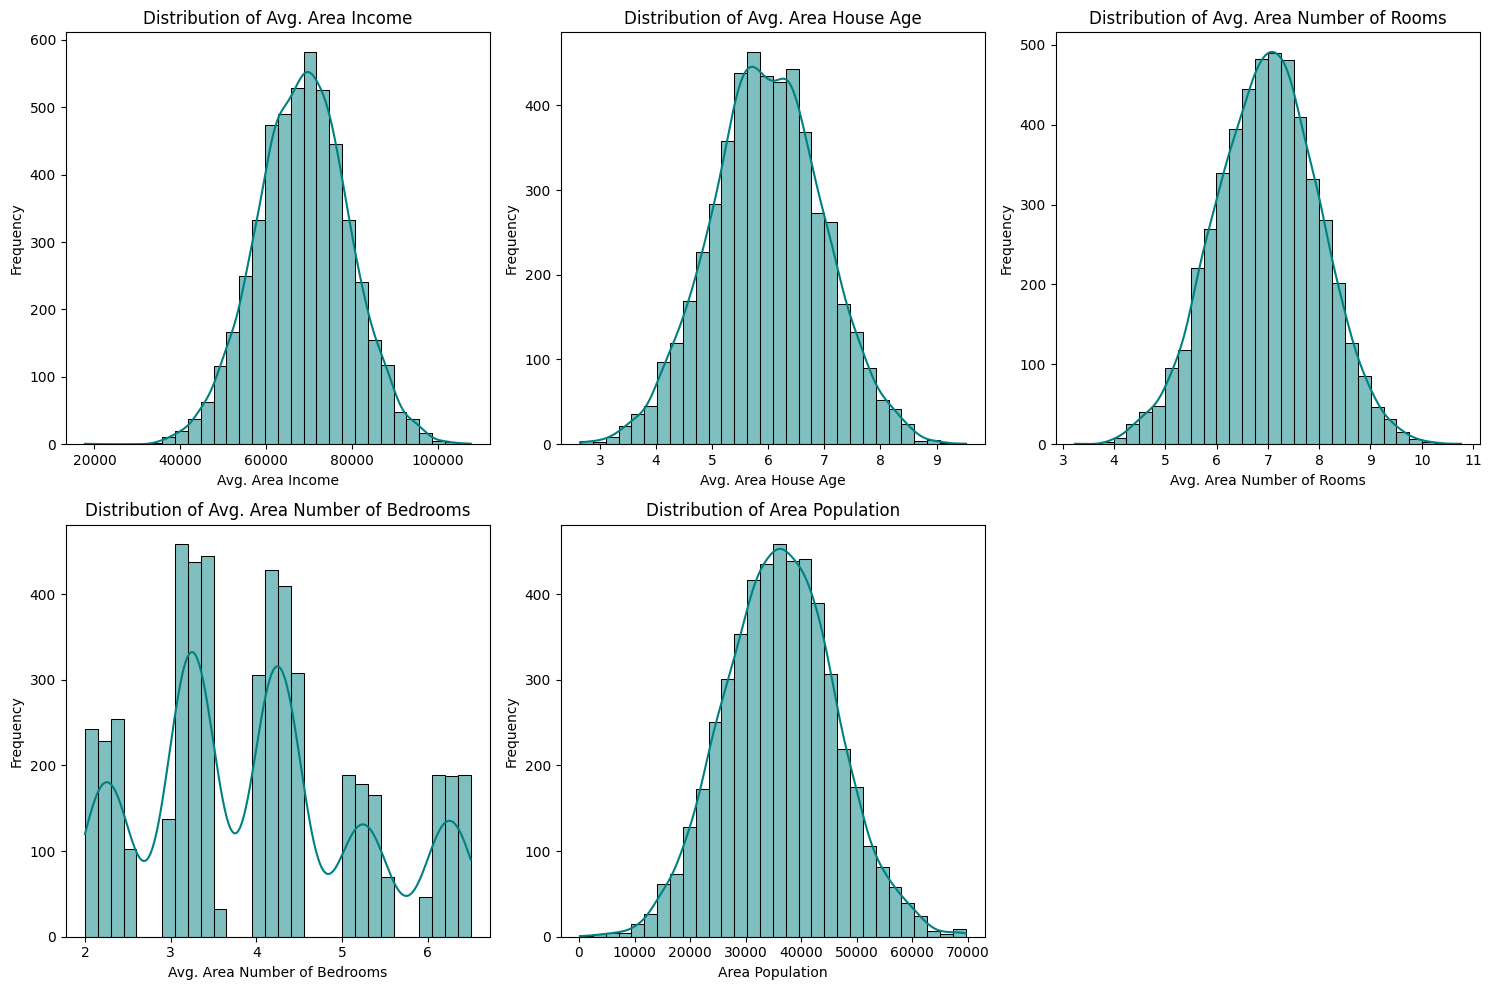

In [10]:
numerical_features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population",
]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
  sns.histplot(df[col], kde=True, ax=axes[i], color="teal", bins=30)
  axes[i].set_title(f"Distribution of {col}", fontsize=12)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("Frequency")
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

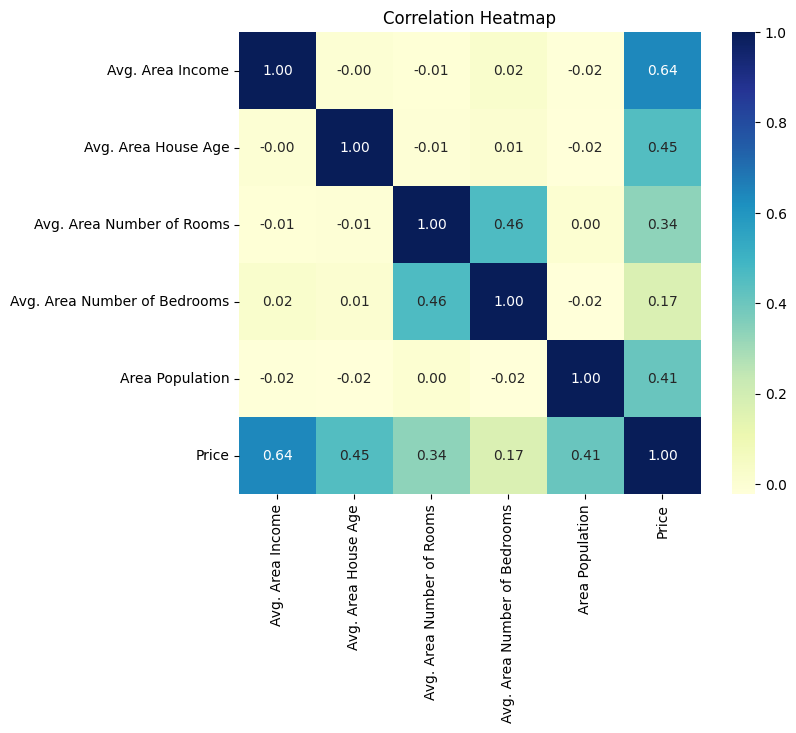

In [11]:
numerical_features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population",
    "Price"
]
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='YlGnBu', square=True)
plt.title('Correlation Heatmap')
plt.show()

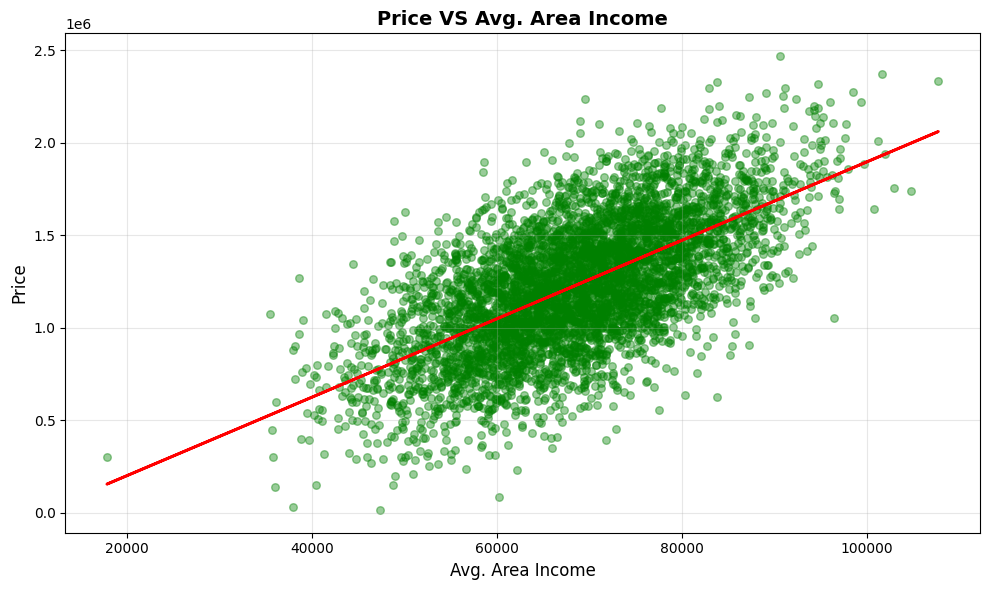

In [12]:
X = df["Avg. Area Income"]
y = df["Price"]
m, c = np.polyfit(X, y, 1)
y_pred_manual = m * X + c

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="green", alpha=0.4, s=30)

# Regression line
plt.plot(
    X,
    y_pred_manual,
    color="red",
    linewidth=2,
    label=f"Regression Line: y = {m:.2f}x + {c:.2f}",
)


plt.xlabel('Avg. Area Income', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Price VS Avg. Area Income', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

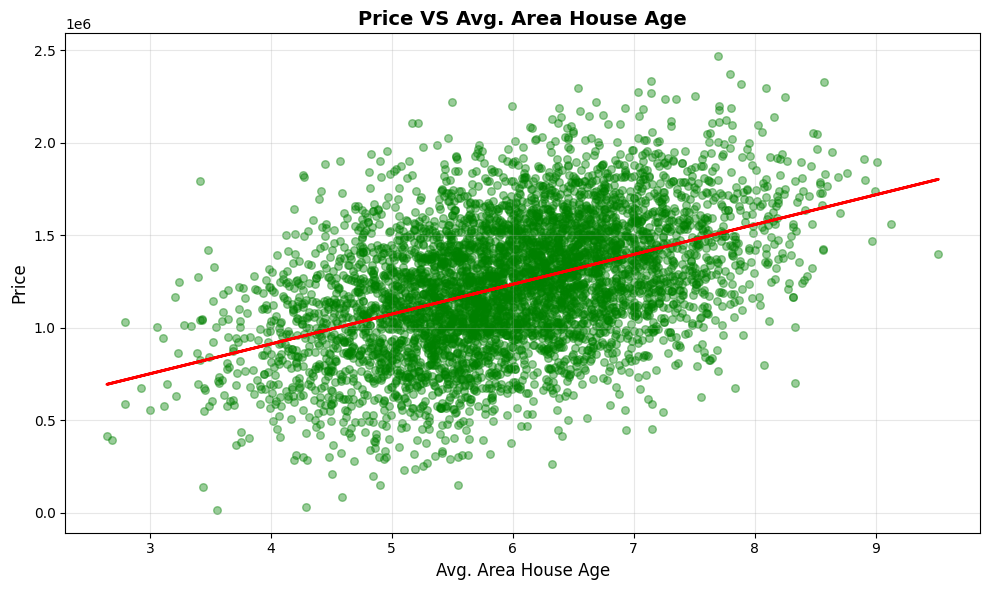

In [13]:
X = df["Avg. Area House Age"]
y = df["Price"]
m, c = np.polyfit(X, y, 1)
y_pred_manual = m * X + c

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="green", alpha=0.4, s=30)

# Regression line
plt.plot(
    X,
    y_pred_manual,
    color="red",
    linewidth=2,
    label=f"Regression Line: y = {m:.2f}x + {c:.2f}",
)


plt.xlabel('Avg. Area House Age', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Price VS Avg. Area House Age', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

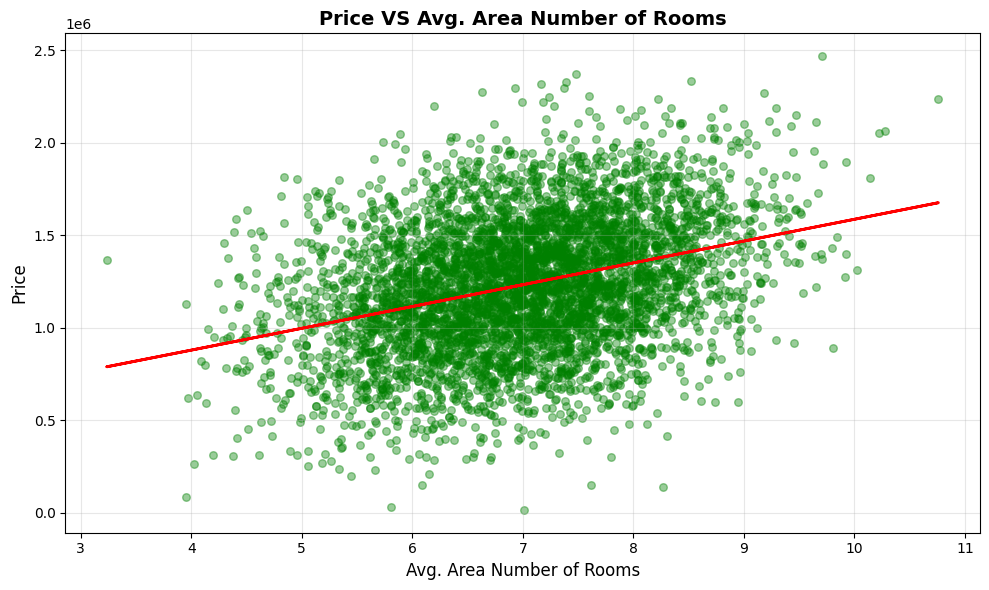

In [14]:
X = df["Avg. Area Number of Rooms"]
y = df["Price"]
m, c = np.polyfit(X, y, 1)
y_pred_manual = m * X + c

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="green", alpha=0.4, s=30)

# Regression line
plt.plot(
    X,
    y_pred_manual,
    color="red",
    linewidth=2,
    label=f"Regression Line: y = {m:.2f}x + {c:.2f}",
)


plt.xlabel('Avg. Area Number of Rooms', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Price VS Avg. Area Number of Rooms', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

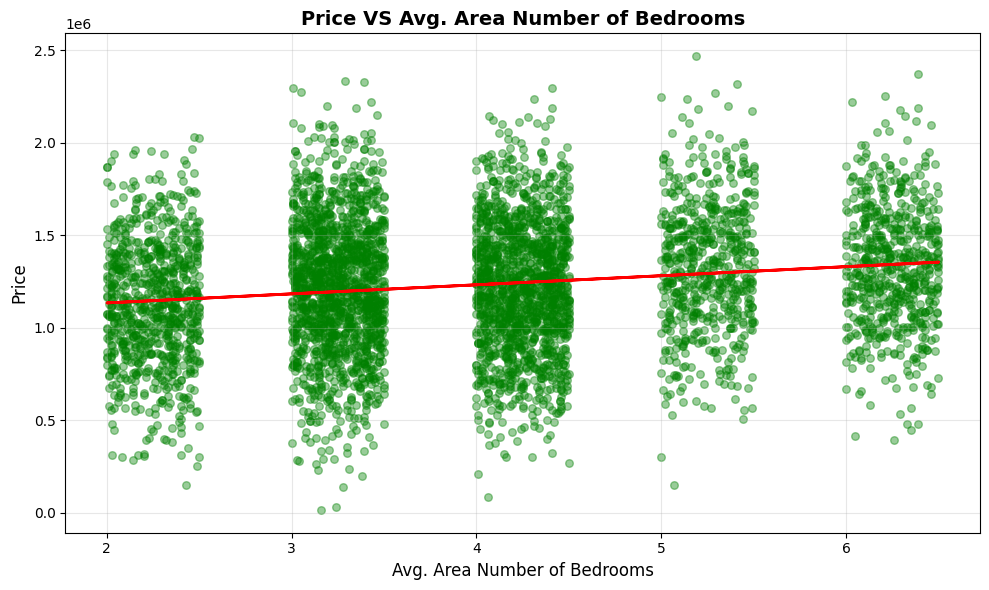

In [15]:
X = df["Avg. Area Number of Bedrooms"]
y = df["Price"]
m, c = np.polyfit(X, y, 1)
y_pred_manual = m * X + c

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="green", alpha=0.4, s=30)

# Regression line
plt.plot(
    X,
    y_pred_manual,
    color="red",
    linewidth=2,
    label=f"Regression Line: y = {m:.2f}x + {c:.2f}",
)


plt.xlabel('Avg. Area Number of Bedrooms', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Price VS Avg. Area Number of Bedrooms', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

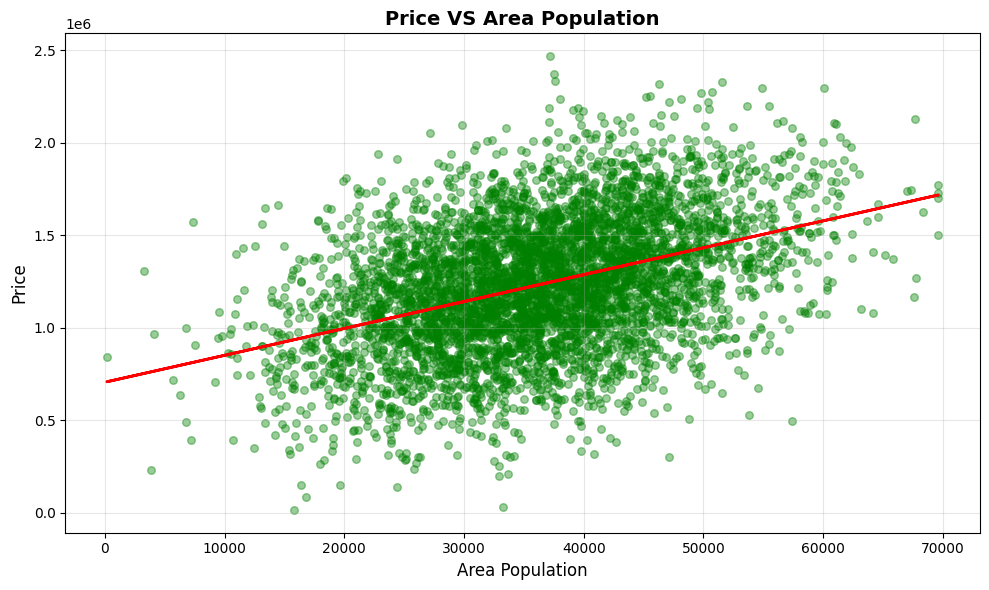

In [16]:
X = df["Area Population"]
y = df["Price"]
m, c = np.polyfit(X, y, 1)
y_pred_manual = m * X + c

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="green", alpha=0.4, s=30)

# Regression line
plt.plot(
    X,
    y_pred_manual,
    color="red",
    linewidth=2,
    label=f"Regression Line: y = {m:.2f}x + {c:.2f}",
)


plt.xlabel('Area Population', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Price VS Area Population', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Observations & Key Findings**

* **Which Features Appear the most important?**
  * **ANS:** **`Avg. Area Income`** (0.64), **`Avg. Area House Age`** (0.45), **`Area Population`** (0.41), and **`Avg. Area Number of Rooms`** (0.35) have the strongest positive correlations with **`Price`**, making them the most important features.

---

* **Are the relationships linear or non-linear?**
  * **ANS:** The scatter plots show high variance, but the relationship is **quite linear**. Although dense clustering obscures the linear flow of the data visually, the underlying trend present in the data is predominantly linear.

---

* **Which features will you use for modeling?**
  * **ANS:** **`Avg. Area Income`**, **`Avg. Area House Age`**, **`Avg. Area Number of Rooms`**, and **`Area Population`** have the greatest effect on **`Price`**, so we will use these features for modeling.

---

* **Which model types might work best?**
  * **ANS:** **Linear Regression**, **Ridge**, & **Lasso** may be a very good fit. Additionally, **KNN** (after applying feature scaling) can also perform well. Given the scattered variance, these models should outperform others.